For alpha=0.006579332246575676, 
 --> we have a minimal Error of 0.036192


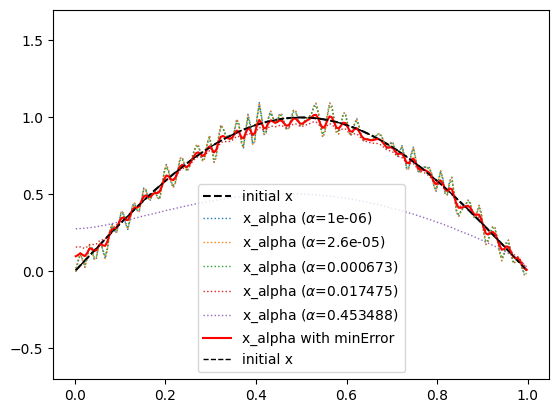

In [ ]:
import numpy as np
from math import pi, sqrt
import matplotlib.pyplot as plt

def k(t,s):
    if s<t:
        return 1/sqrt(pi*(t-s))
    else:
        return 0

N = 200 #stepsize
h = 1/N

s_grid = np.array([i*h + h/2 for i in range(N)])
t_grid = np.array([i*h for i in range(1,N+1)])

A = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        A[i,j] = h * k(t_grid[i], s_grid[j])

# FUNCTION
x = lambda s: np.sin( s*np.pi )

x_grid = x(s_grid)
y_grid = A @ x_grid

np.random.seed(42)
d = np.random.randn(N)
d = d/np.linalg.norm(d) * np.linalg.norm(y_grid) * 0.01
y_delta = y_grid + d

# # region: plot

# plt.plot(x_grid,label="x_grid")

# plt.plot(y_delta, label="y_delta")
# plt.plot(y_grid, label="y_grid")
# plt.legend()
# plt.show()
# # endregion

# region: TIKHONOV by SUM
U, sv, V_T = np.linalg.svd(A,compute_uv=True)       

k_top = min(100,N)              # biggest sum index
a_array = 10**np.linspace(-6,1,k_top)   # at which values for alpha to look at

x_alphas = np.zeros(( len(a_array), N ))    # save x_grid for all alphas
Tik_Error = np.zeros(len(a_array))          # compute relative error for each alpha

plt.plot(s_grid,x_grid,label='initial x',linestyle="--",color='black')

for i,a in enumerate(a_array):
    #compute sum for each alpha
    for k in range(k_top):
        factor = sv[k]/ (sv[k]**2 + a)
        x_alphas[i,:] = x_alphas[i,:] + factor * np.dot(y_delta, U[:,k]) * V_T[k,:]
        factor = 1

    Tik_Error[i] = np.linalg.norm(x_grid - x_alphas[i])/np.linalg.norm(x_grid)
    if i%20 == 0:
        plt.plot(s_grid,x_alphas[i],label=f"x_alpha ($\\alpha$={round(a,6)})",linestyle=":",lw=1)

minError_Tik = min(Tik_Error)
Error_index = np.argmin(Tik_Error)
minError_alpha = a_array[Error_index]
print(f"For alpha={minError_alpha}, \n --> we have a minimal Error of {round(minError_Tik,6)}")

plt.plot(s_grid,x_alphas[Error_index],color='red',label='x_alpha with minError')
plt.plot(s_grid,x_grid,label='initial x',linestyle="--",color='black',lw=1)
plt.legend()
plt.ylim(-0.7,1.7)
# plt.grid(True)
plt.show()

plt.semilogx(a_array,Tik_Error,label=f"error dep. on $\\alpha$ (k={k_top})")
plt.axvline(minError_alpha,color='grey',linestyle='--')
plt.grid(True)
plt.show()
# endregion

# region: TIKHONOV by LEAST-SQUARE



# endregion

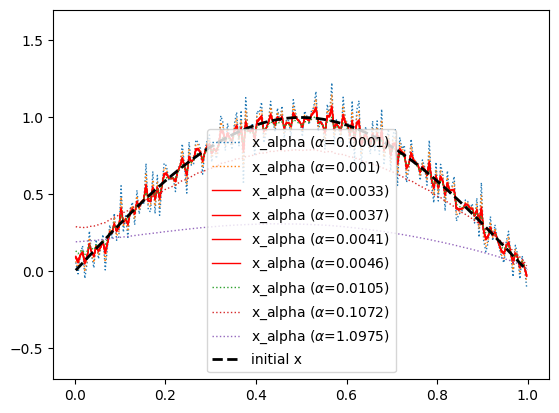

In [3]:
k_top = 100
a_array = 10**np.linspace(-4,1,k_top)
error_Tik = np.zeros(len(a_array))

for k,alpha in enumerate(a_array):
    A_Tik = np.vstack([A,np.sqrt(alpha) * np.eye(N)])
    y_Tik = np.concatenate([y_delta,np.zeros(N)])
    
    x_Tik, residuals, rank, s = np.linalg.lstsq(A_Tik, y_Tik, rcond=None)
    error_Tik[k] = np.linalg.norm(x_grid - x_Tik) / np.linalg.norm(x_grid)

    if k%20 == 0:
        plt.plot(s_grid,x_Tik,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=1,linestyle=":")
    #plot the graph, with the least error:
    if 0.003 <= alpha <= 0.005:
        plt.plot(s_grid,x_Tik,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=1,linestyle="-",color='red')

plt.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=2) 
plt.legend()
plt.ylim(-0.7,1.7)
# plt.title("Tikhonov Regularisation")
plt.show()




For alpha=0.1873817422860383, 
 --> we have a minimal Error of 0.015542
For alpha=1000.0, 
 --> we have a minimal Error of 0.002872


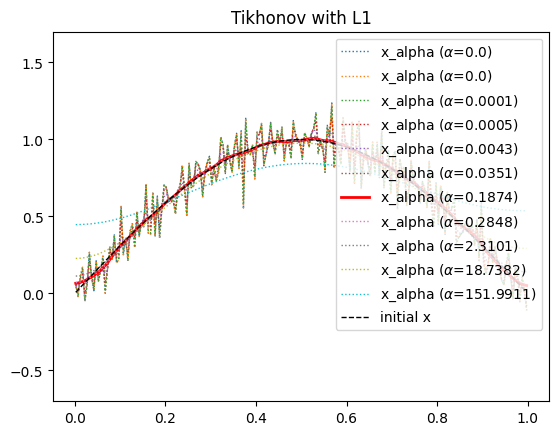

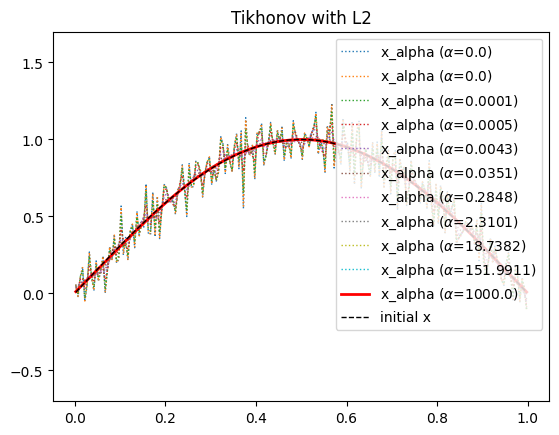

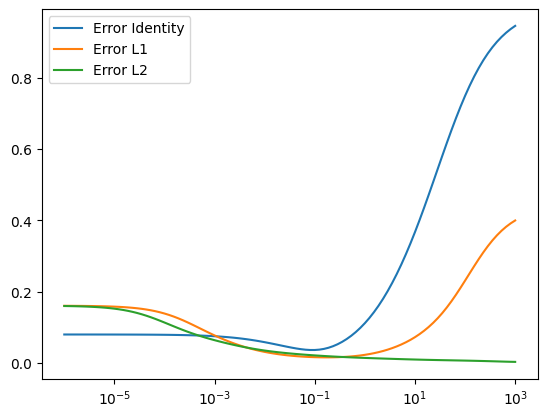

In [20]:
L1 = np.zeros((N-1,N))
L2 = np.zeros((N-2,N))

for i in range(N-2):
    L1[i,i] = -1
    L1[i,i+1] = 1

    L2[i,i] = 1
    L2[i,i+1] = -2
    L2[i,i+2] = 1

L1[N-2,N-2] = -1
L1[N-2,N-1] = 1

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

k_top = min(100,N)
a_array = 10**np.linspace(-6,3,k_top)

error_Tik1 = np.zeros(len(a_array))
error_Tik2 = np.zeros(len(a_array))

for k,alpha in enumerate(a_array):
    A_Tik1 = np.vstack([A,np.sqrt(alpha) * L1])
    y_Tik1 = np.concatenate([y_delta,np.zeros(N-1)])

    A_Tik2 = np.vstack([A,np.sqrt(alpha) * L2])
    y_Tik2 = np.concatenate([y_delta,np.zeros(N-2)])
    
    x_Tik1, residuals, rank, s = np.linalg.lstsq(A_Tik1, y_Tik1, rcond=None)
    error_Tik1[k] = np.linalg.norm(x_grid - x_Tik1) / np.linalg.norm(x_grid)

    x_Tik2, residuals, rank, s = np.linalg.lstsq(A_Tik2, y_Tik2, rcond=None)
    error_Tik2[k] = np.linalg.norm(x_grid - x_Tik2) / np.linalg.norm(x_grid)

    if k%10 == 0:
        ax1.plot(s_grid,x_Tik1,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=1,linestyle=":")
        ax2.plot(s_grid,x_Tik2,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=1,linestyle=":")
        
    #plot the graph, with the least error:
    if 0.17 <= alpha <= 0.19:
        ax1.plot(s_grid,x_Tik1,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=2,linestyle="-",color='red')
    
ax2.plot(s_grid,x_Tik2,label=f"x_alpha ($\\alpha$={round(alpha,4)})",lw=2,linestyle="-",color='red')


#L1
minError_Tik1 = min(error_Tik1)
Error_index1 = np.argmin(error_Tik1)
minError_alpha1 = a_array[Error_index1]
print(f"For alpha={minError_alpha1}, \n --> we have a minimal Error of {round(minError_Tik1,6)}")
#L2
minError_Tik2 = min(error_Tik2)
Error_index2 = np.argmin(error_Tik2)
minError_alpha2 = a_array[Error_index2]
print(f"For alpha={minError_alpha2}, \n --> we have a minimal Error of {round(minError_Tik2,6)}")

# plot
ax1.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=1) 
ax1.legend()
ax1.set_ylim(-0.7,1.7)
ax1.set_title("Tikhonov with L1")

ax2.plot(s_grid,x_grid,label="initial x",linestyle='--',color='black',lw=1) 
ax2.legend()
ax2.set_ylim(-0.7,1.7)
ax2.set_title("Tikhonov with L2")
plt.show()

# plot error
plt.semilogx(a_array,Tik_Error,label="Error Identity")
plt.semilogx(a_array,error_Tik1,label="Error L1")
plt.semilogx(a_array,error_Tik2, label="Error L2")
plt.legend()
plt.show()
